In [23]:
import numpy as np
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Colab Notebooks/optimisatio"
df_1 = pd.read_csv('student_habits_performance.csv')
df_1.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/optimisatio


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [24]:
df = df_1.drop(columns=['student_id', 'exam_score'])

In [25]:
df_numeric = df.select_dtypes(exclude='object')
df_object = df.select_dtypes(include='object')

In [26]:
df_numeric = df_numeric.assign(**{col + "_carre": df_numeric[col]**2 for col in df_numeric.columns})
df_numeric.head(5)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,age_carre,study_hours_per_day_carre,social_media_hours_carre,netflix_hours_carre,attendance_percentage_carre,sleep_hours_carre,exercise_frequency_carre,mental_health_rating_carre
0,23,0.0,1.2,1.1,85.0,8.0,6,8,529,0.00,1.44,1.21,7225.00,64.00,36,64
1,20,6.9,2.8,2.3,97.3,4.6,6,8,400,47.61,7.84,5.29,9467.29,21.16,36,64
2,21,1.4,3.1,1.3,94.8,8.0,1,1,441,1.96,9.61,1.69,8987.04,64.00,1,1
3,23,1.0,3.9,1.0,71.0,9.2,4,1,529,1.00,15.21,1.00,5041.00,84.64,16,1
4,19,5.0,4.4,0.5,90.9,4.9,3,1,361,25.00,19.36,0.25,8262.81,24.01,9,1


In [27]:
df_final = pd.concat([df_numeric , df_object] , axis=1 )

In [28]:
# Vérification du type de chaque variable
df_final.dtypes

,0
age,int64
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
attendance_percentage,float64
sleep_hours,float64
exercise_frequency,int64
mental_health_rating,int64
age_carre,int64
study_hours_per_day_carre,float64


In [29]:
# Vérification des valeurs manquantes

df_manque = df_final.isnull().sum()
df_manque[df_manque > 0]

,0
parental_education_level,91


In [30]:
# Imputation de la variable parental_education_level par le mode
df_final['parental_education_level'] = df_final['parental_education_level'].fillna(df_final['parental_education_level'].mode()[0])

In [31]:
df_final.isnull().sum()

,0
age,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
attendance_percentage,0
sleep_hours,0
exercise_frequency,0
mental_health_rating,0
age_carre,0
study_hours_per_day_carre,0


In [32]:
X = df_final
y = df_1.exam_score

In [33]:
for col in ['gender', 'part_time_job', 'extracurricular_participation',
            'diet_quality', 'parental_education_level', 'internet_quality']:
    print(f"{col} : {df_final[col].unique()}")

gender : ['Female' 'Male' 'Other']
part_time_job : ['No' 'Yes']
extracurricular_participation : ['Yes' 'No']
diet_quality : ['Fair' 'Good' 'Poor']
parental_education_level : ['Master' 'High School' 'Bachelor']
internet_quality : ['Average' 'Poor' 'Good']


In [34]:
# Encodage des variables ordinales
diet_map = {'Poor': 0, 'Fair': 1, 'Good': 2}
X['diet_quality'] = X['diet_quality'].map(diet_map)

education_map = {'High School': 0, 'Bachelor': 1, 'Master': 2}
X['parental_education_level'] = X['parental_education_level'].map(education_map)

internet_map = {'Poor': 0, 'Average': 1, 'Good': 2}
X['internet_quality'] = X['internet_quality'].map(internet_map)

# Encodage des variables nominales
gender_map = {'Female': 0, 'Male': 1, 'Other': 2}
X['gender'] = X['gender'].map(gender_map)

job_map = {'No': 0, 'Yes': 1}
X['part_time_job'] = X['part_time_job'].map(job_map)

extra_map = {'No': 0, 'Yes': 1}
X['extracurricular_participation'] = X['extracurricular_participation'].map(extra_map)

In [35]:
X.head()


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,age_carre,study_hours_per_day_carre,...,attendance_percentage_carre,sleep_hours_carre,exercise_frequency_carre,mental_health_rating_carre,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
0,23,0.0,1.2,1.1,85.0,8.0,6,8,529,0.00,...,7225.00,64.00,36,64,0,0,1,2,1,1
1,20,6.9,2.8,2.3,97.3,4.6,6,8,400,47.61,...,9467.29,21.16,36,64,0,0,2,0,1,0
2,21,1.4,3.1,1.3,94.8,8.0,1,1,441,1.96,...,8987.04,64.00,1,1,1,0,0,0,0,0
3,23,1.0,3.9,1.0,71.0,9.2,4,1,529,1.00,...,5041.00,84.64,16,1,0,0,0,2,2,1
4,19,5.0,4.4,0.5,90.9,4.9,3,1,361,25.00,...,8262.81,24.01,9,1,0,0,1,2,2,0


In [36]:
# Normalisation
mean = X.mean()
std = X.std()

X_scaled = (X - mean) / std
print(X_scaled.describe().round(2))

           age  study_hours_per_day  social_media_hours  netflix_hours  \
count  1000.00              1000.00             1000.00        1000.00   
mean     -0.00                -0.00               -0.00          -0.00   
std       1.00                 1.00                1.00           1.00   
min      -1.52                -2.42               -2.14          -1.69   
25%      -0.76                -0.65               -0.69          -0.76   
50%      -0.22                -0.03               -0.00          -0.02   
75%       1.08                 0.65                0.68           0.66   
max       1.52                 3.23                4.00           3.33   

       attendance_percentage  sleep_hours  exercise_frequency  \
count                1000.00      1000.00             1000.00   
mean                    0.00        -0.00                0.00   
std                     1.00         1.00                1.00   
min                    -2.99        -2.67               -1.50   
25%     

In [37]:
# Conversion en listes Python
X_tab = X_scaled.values.tolist()
y_tab = y.values.tolist()



# Ajout de 1 au début de chaque ligne (biais)
X_b = X_tab  # on garde juste X normal

# Initialiser les poids à 0
n_features = len(X_tab[0])
w = [0] * n_features
b = 0  # biais séparé



In [38]:
# Implémentation de la régression linéaire
def regression_lineaire(X, w, b):
    y_pred = []
    for i in range(len(X)):
        val = 0
        for j in range(len(w)):
            val += w[j] * X[i][j]
        val += b  # ← important
        y_pred.append(val)
    return y_pred

In [39]:
# Fonction MSE
def mse(y_attendu, y_pred):
    m = len(y_attendu)
    sum = 0
    for i in range(m):
        sum += (y_attendu[i] - y_pred[i])**2
    return sum / m

In [40]:
# Dérivées partielles
def derivee_w(X, y_true, w, y_pred):
    m = len(y_true)
    grads = []

    for j in range(len(w)):
        deriv_w = 0
        for i in range(m):
            deriv_w += (y_pred[i] - y_true[i]) * X[i][j]
        grads.append((2/m) * deriv_w)

    return grads

def derivee_b(y_true, y_pred):
    m = len(y_true)
    grad_b = 0

    for i in range(m):
        grad_b += (y_pred[i] - y_true[i])

    return (2/m) * grad_b


In [41]:
# Gradient Descent
alpha = 0.1
n_iter = 2000
list_cout = []

for i in range(n_iter):
    # 1. Prédiction
    y_pred = regression_lineaire(X_b, w, b)

    # 2. Coût
    cout = mse(y_tab, y_pred)
    list_cout.append(cout)

    # 3. Gradients
    dw = derivee_w(X_b, y_tab, w, y_pred)
    db = derivee_b(y_tab, y_pred)

    # 4. Mise à jour des poids
    for j in range(len(w)):
        w[j] = w[j] - alpha * dw[j]

    # 5. Mise à jour du biais
    b = b - alpha * db





In [42]:
colonnes = list(X.columns)

print("Coefficients :")
for i in range(len(w)):
    print(f"{colonnes[i]} : {w[i]:.4f}")

print(f"Biais : {b:.4f}")

Coefficients :
age : 0.1165
study_hours_per_day : 17.2472
social_media_hours : -4.0481
netflix_hours : -2.6155
attendance_percentage : 1.4978
sleep_hours : 1.4901
exercise_frequency : 2.4191
mental_health_rating : 5.3510
age_carre : -0.1488
study_hours_per_day_carre : -3.2861
social_media_hours_carre : 1.0351
netflix_hours_carre : 0.1896
attendance_percentage_carre : -0.0828
sleep_hours_carre : 0.9598
exercise_frequency_carre : 0.5865
mental_health_rating_carre : 0.2084
gender : 0.0871
part_time_job : 0.1348
diet_quality : -0.2332
parental_education_level : -0.0089
internet_quality : -0.1714
extracurricular_participation : 0.0335
Biais : 69.6015


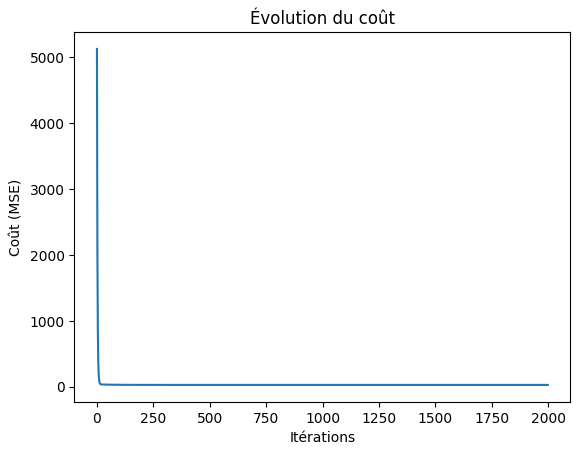

In [43]:

plt.plot(range(n_iter), list_cout)
plt.xlabel("Itérations")
plt.ylabel("Coût (MSE)")
plt.title("Évolution du coût")
plt.show()